# Lab 4 : Fuzzy Foundations & Visualisation

In [1]:
import sys
!{sys.executable} -m pip install scikit-fuzzy


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

# Configure matplotlib for better display
plt.rcParams['figure.figsize'] = [10, 5]
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Crisp Sets vs. Fuzzy Sets

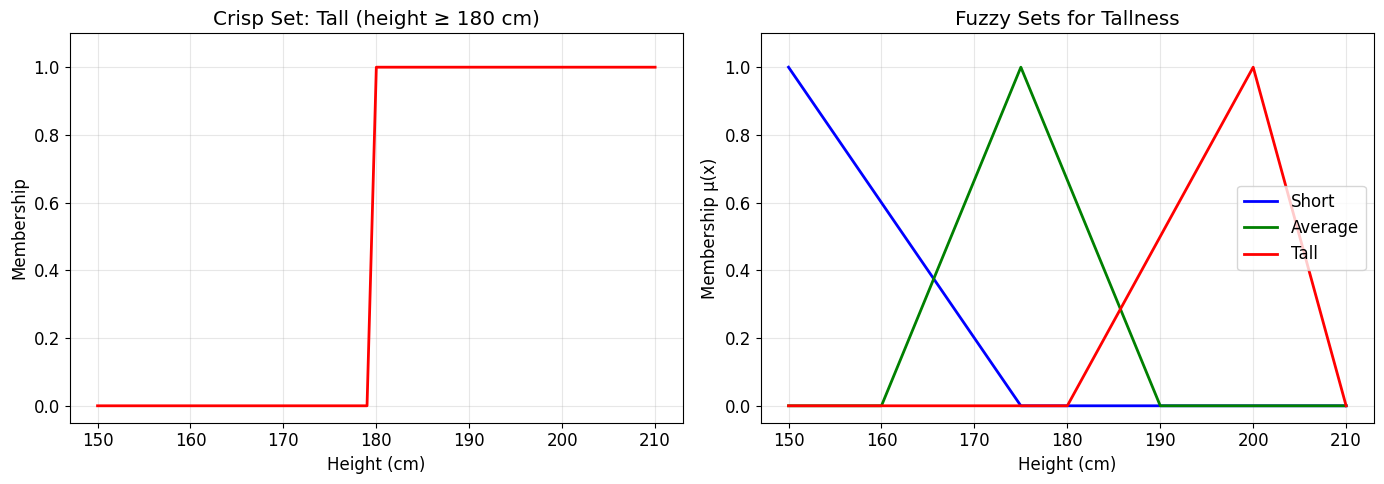

A person who is 184 cm tall:
  μ_average(184) = 0.40
  μ_tall(184)    = 0.20
  → Partial membership in MULTIPLE sets simultaneously.


In [3]:
# Universe of discourse: height in cm
x_height = np.arange(150, 211, 1)
# --- Crisp set: tall if height >= 180 --
crisp_tall = np.where(x_height >= 180, 1.0, 0.0)
# --- Fuzzy sets --
short   = fuzz.trimf(x_height, [150, 150, 175])
# TODO: create here the "average" and "tall" sets
average = fuzz.trimf(x_height, [160, 175, 190])
tall    = fuzz.trimf(x_height, [180, 200, 210])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
# Crisp
ax1.plot(x_height, crisp_tall, 'r-', linewidth=2)
ax1.set_title('Crisp Set: Tall (height ≥ 180 cm)')
ax1.set_xlabel('Height (cm)')
ax1.set_ylabel('Membership')
ax1.set_ylim(-0.05, 1.1)
# Fuzzy
ax2.plot(x_height, short,   'b-',  linewidth=2, label='Short')
ax2.plot(x_height, average, 'g-',  linewidth=2, label='Average')
ax2.plot(x_height, tall,    'r-',  linewidth=2, label='Tall')
ax2.set_title('Fuzzy Sets for Tallness')
ax2.set_xlabel('Height (cm)')
ax2.set_ylabel('Membership μ(x)')
ax2.set_ylim(-0.05, 1.1)
ax2.legend()
plt.tight_layout()
plt.show()
# Demonstrate partial membership
height = 184
mu_avg = fuzz.interp_membership(x_height, average, height)
# TODO: compute here the membership value for "tall"
mu_tall = fuzz.interp_membership(x_height, tall, height)

print(f"A person who is {height} cm tall:")
print(f"  μ_average({height}) = {mu_avg:.2f}")
print(f"  μ_tall({height})    = {mu_tall:.2f}")
print(f"  → Partial membership in MULTIPLE sets simultaneously.")

## 2. Common Membership Functions

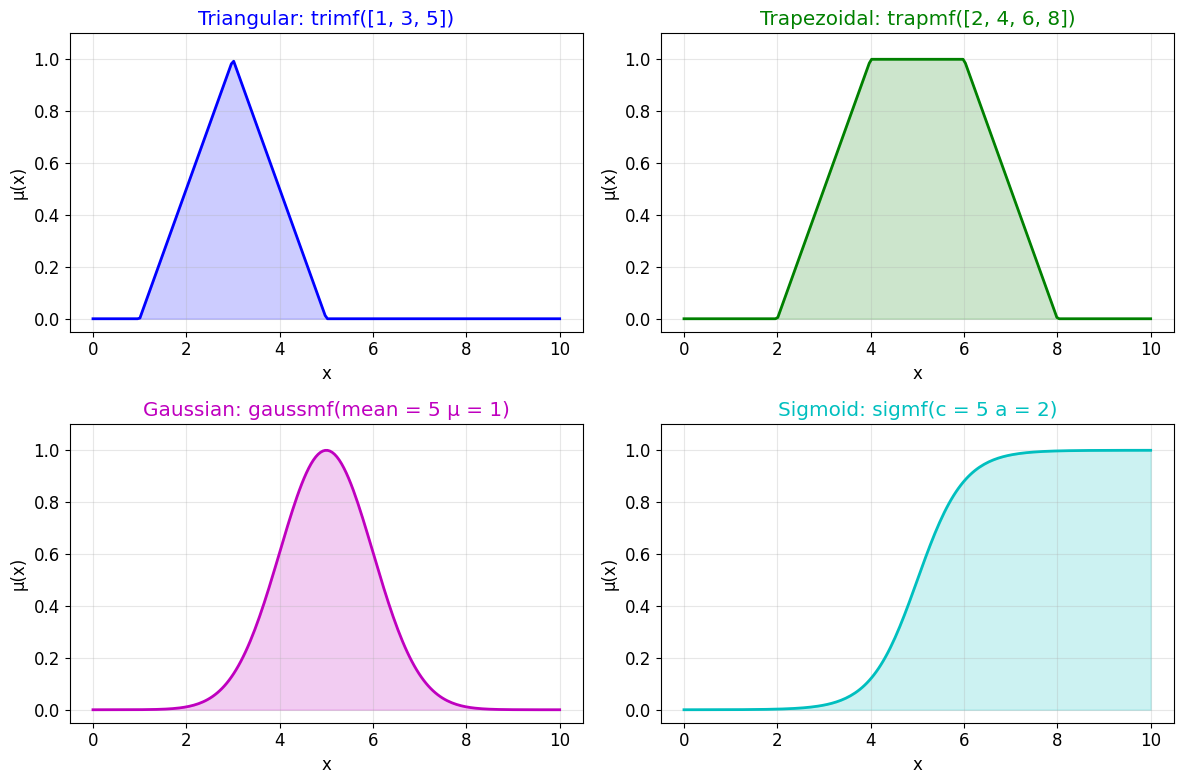

In [4]:
x = np.linspace(0, 10, 200)

# Triangular: peak at 3
# TODO: create here a triangular membership function
mf_tri = fuzz.trimf(x, [1, 3, 5])

# Trapezoidal: plateau from 4 to 6
# TODO: create here a trapezoidal membership function
mf_trap = fuzz.trapmf(x, [2, 4, 6, 8])

# Gaussian: centred at 5, sigma=1
# TODO: create here a gaussian membership function
mf_gauss = fuzz.gaussmf(x, 5, 1)

# Sigmoid: inflection at 5, slope=2 (positive = rising)
# TODO: create here a sigmoidal membership function
mf_sigmoid = fuzz.sigmf(x, 5, 2)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].plot(x, mf_tri, 'b-', linewidth=2)

axes[0, 0].set_title('Triangular: trimf([1, 3, 5])', color='b')
axes[0, 0].fill_between(x, mf_tri, alpha=0.2, color='b')
# TODO: code here to visualise the other 3 membership functions
axes[0, 1].plot(x, mf_trap, 'g-', linewidth=2)
axes[0, 1].set_title('Trapezoidal: trapmf([2, 4, 6, 8])', color='g')
axes[0, 1].fill_between(x, mf_trap, alpha=0.2, color='g')

axes[1, 0].plot(x, mf_gauss, 'm-', linewidth=2)
axes[1, 0].set_title('Gaussian: gaussmf(mean = 5 μ = 1)', color='m')
axes[1, 0].fill_between(x, mf_gauss, alpha=0.2, color='m')

axes[1, 1].plot(x, mf_sigmoid, 'c-', linewidth=2)
axes[1, 1].set_title('Sigmoid: sigmf(c = 5 a = 2)', color='c')
axes[1, 1].fill_between(x, mf_sigmoid, alpha=0.2, color='c')

for ax in axes.flat:
    ax.set_xlabel('x')
    ax.set_ylabel('μ(x)')
    ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.show()

## Exercise 2.2: The Dapping Example — Defining Linguistic Variables

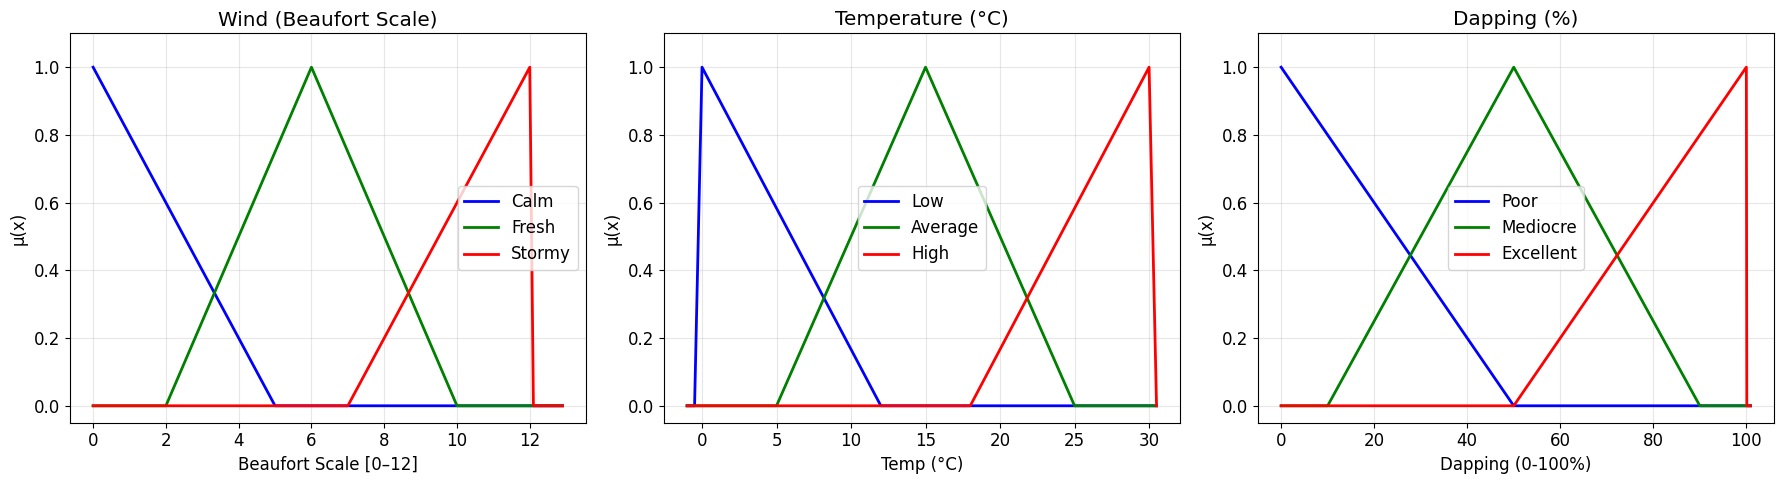

In [7]:
# --- Define universes of discourse --
x_wind = np.arange(0, 13, 0.1)     
# Beaufort scale 0-12
# TODO: code here the universes of discurse for

#       temperature and dapping effectiveness
# --- Wind membership functions --
wind_calm   = fuzz.trimf(x_wind, [0, 0, 5])
wind_fresh  = fuzz.trimf(x_wind, [2, 6, 10])
wind_stormy = fuzz.trimf(x_wind, [7, 12, 12])

# --- Temperature membership functions --
x_temp = np.arange(-1, 31, 0.5)
temp_low   = fuzz.trimf(x_temp, [0, 0, 12])
temp_average   = fuzz.trimf(x_temp, [5, 15, 25])
temp_high   = fuzz.trimf(x_temp, [18, 30, 30])

# --- Dapping membership functions --
x_dap = np.arange(0, 101, 0.1)
dap_poor     = fuzz.trimf(x_dap, [0, 0, 50])
dap_mediocre  = fuzz.trimf(x_dap, [10, 50, 90])
dap_excellent    = fuzz.trimf(x_dap, [50, 100, 100])

# --- Plot --
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
# Wind
ax1.plot(x_wind, wind_calm,   'b-', linewidth=2, label='Calm')
ax1.plot(x_wind, wind_fresh,  'g-', linewidth=2, label='Fresh')
ax1.plot(x_wind, wind_stormy, 'r-', linewidth=2, label='Stormy')
ax1.set_title('Wind (Beaufort Scale)')
ax1.set_xlabel('Beaufort Scale [0–12]')
ax1.set_ylabel('μ(x)')
ax1.legend()

# Temperature
# TODO: code here the figure for temperature\

ax2.plot(x_temp, temp_low, 'b-', linewidth=2, label='Low')
ax2.plot(x_temp, temp_average, 'g-', linewidth=2, label='Average')
ax2.plot(x_temp, temp_high, 'r-', linewidth=2, label='High')
ax2.set_title('Temperature (°C)')
ax2.set_xlabel('Temp (°C)')
ax2.set_ylabel('μ(x)')
ax2.legend()

# Dapping
# TODO: code here the figure for dapping

ax3.plot(x_dap, dap_poor, 'b-', linewidth=2, label='Poor')
ax3.plot(x_dap, dap_mediocre, 'g-', linewidth=2, label='Mediocre')
ax3.plot(x_dap, dap_excellent, 'r-', linewidth=2, label='Excellent')
ax3.set_title('Dapping (%)')
ax3.set_xlabel('Dapping (0-100%)')
ax3.set_ylabel('μ(x)')
ax3.legend()

for ax in [ax1, ax2, ax3]:
    ax.set_ylim(-0.05, 1.1)
plt.tight_layout()
plt.show()


## Exercise 2.3: Computing Membership Degrees


In [8]:
# Crisp inputs
wind_val = 8
temp_val = 10

# Fuzzify wind
mu_calm = fuzz.interp_membership(x_wind, wind_calm, wind_val)
mu_fresh = fuzz.interp_membership(x_wind, wind_fresh, wind_val)
mu_stormy = fuzz.interp_membership(x_wind, wind_stormy, wind_val)

# Fuzzify temperature
# TODO: code the temperature fuzzification here
mu_low = fuzz.interp_membership(x_temp, temp_low, temp_val)
mu_average = fuzz.interp_membership(x_temp, temp_average, temp_val)
mu_high = fuzz.interp_membership(x_temp, temp_high, temp_val)

print(f"Fuzzification for wind = {wind_val}, temperature = {temp_val}")
print(f"{'─' * 45}")
print(f" μ_calm({wind_val}) = {mu_calm:.4f}")
print(f" μ_fresh({wind_val}) = {mu_fresh:.4f}")
print(f" μ_stormy({wind_val}) = {mu_stormy:.4f}")
print()
print(f" μ_low({temp_val}) = {mu_low:.4f}")
print(f" μ_average({temp_val}) = {mu_average:.4f}")
print(f" μ_high({temp_val}) = {mu_high:.4f}")


Fuzzification for wind = 8, temperature = 10
─────────────────────────────────────────────
 μ_calm(8) = 0.0000
 μ_fresh(8) = 0.5000
 μ_stormy(8) = 0.2000

 μ_low(10) = 0.1667
 μ_average(10) = 0.5000
 μ_high(10) = 0.0000


## Exercise 3.1: Implement Hedges from Scratch G

In [10]:
def hedge_very(mu):
 """Very: μ^2 (concentration)"""
 return mu ** 2
# TODO: code all the remaining hedge functions here
## Tip 1: use NumPy's "where" function to code
## the "hedge_indeed" function
## Tip 2: see the Exercise 3.2 code cell for the 
## names of the functions

def hedge_extremely(mu):
    """Extremely: μ^3 (more concentration)"""
    return mu ** 3

def hedge_very_very(mu):
    """Very Very: μ^4 (even more concentration)"""
    return mu ** 4

def hedge_slightly(mu):
    """Slightly: sqrt(μ) (dilation)"""
    return mu ** 1.7

def hedge_a_little(mu):
    """A little bit: μ^(1/3) (more dilation)"""
    return mu ** 1.3

def hedge_more_or_less(mu):
    """More or less: μ^(1/2) (dilation)"""
    return mu ** 0.5

def hedge_somewhat(mu):
    """Somewhat: μ^(1/4) (more dilation)"""
    return mu ** (1/3)

def hedge_indeed(mu):
    """Indeed: if μ < 0.5 then 2*μ^2 else 1 - 2*(1-μ)^2"""
    return np.where(mu < 0.5, 2 * mu ** 2, 1 - 2 * (1 - mu) ** 2)

def hedge_not(mu):
    """Not: 1 - μ (negation)"""
    return 1 - mu


## Exercise 3.2: Visualise Hedge Effects 

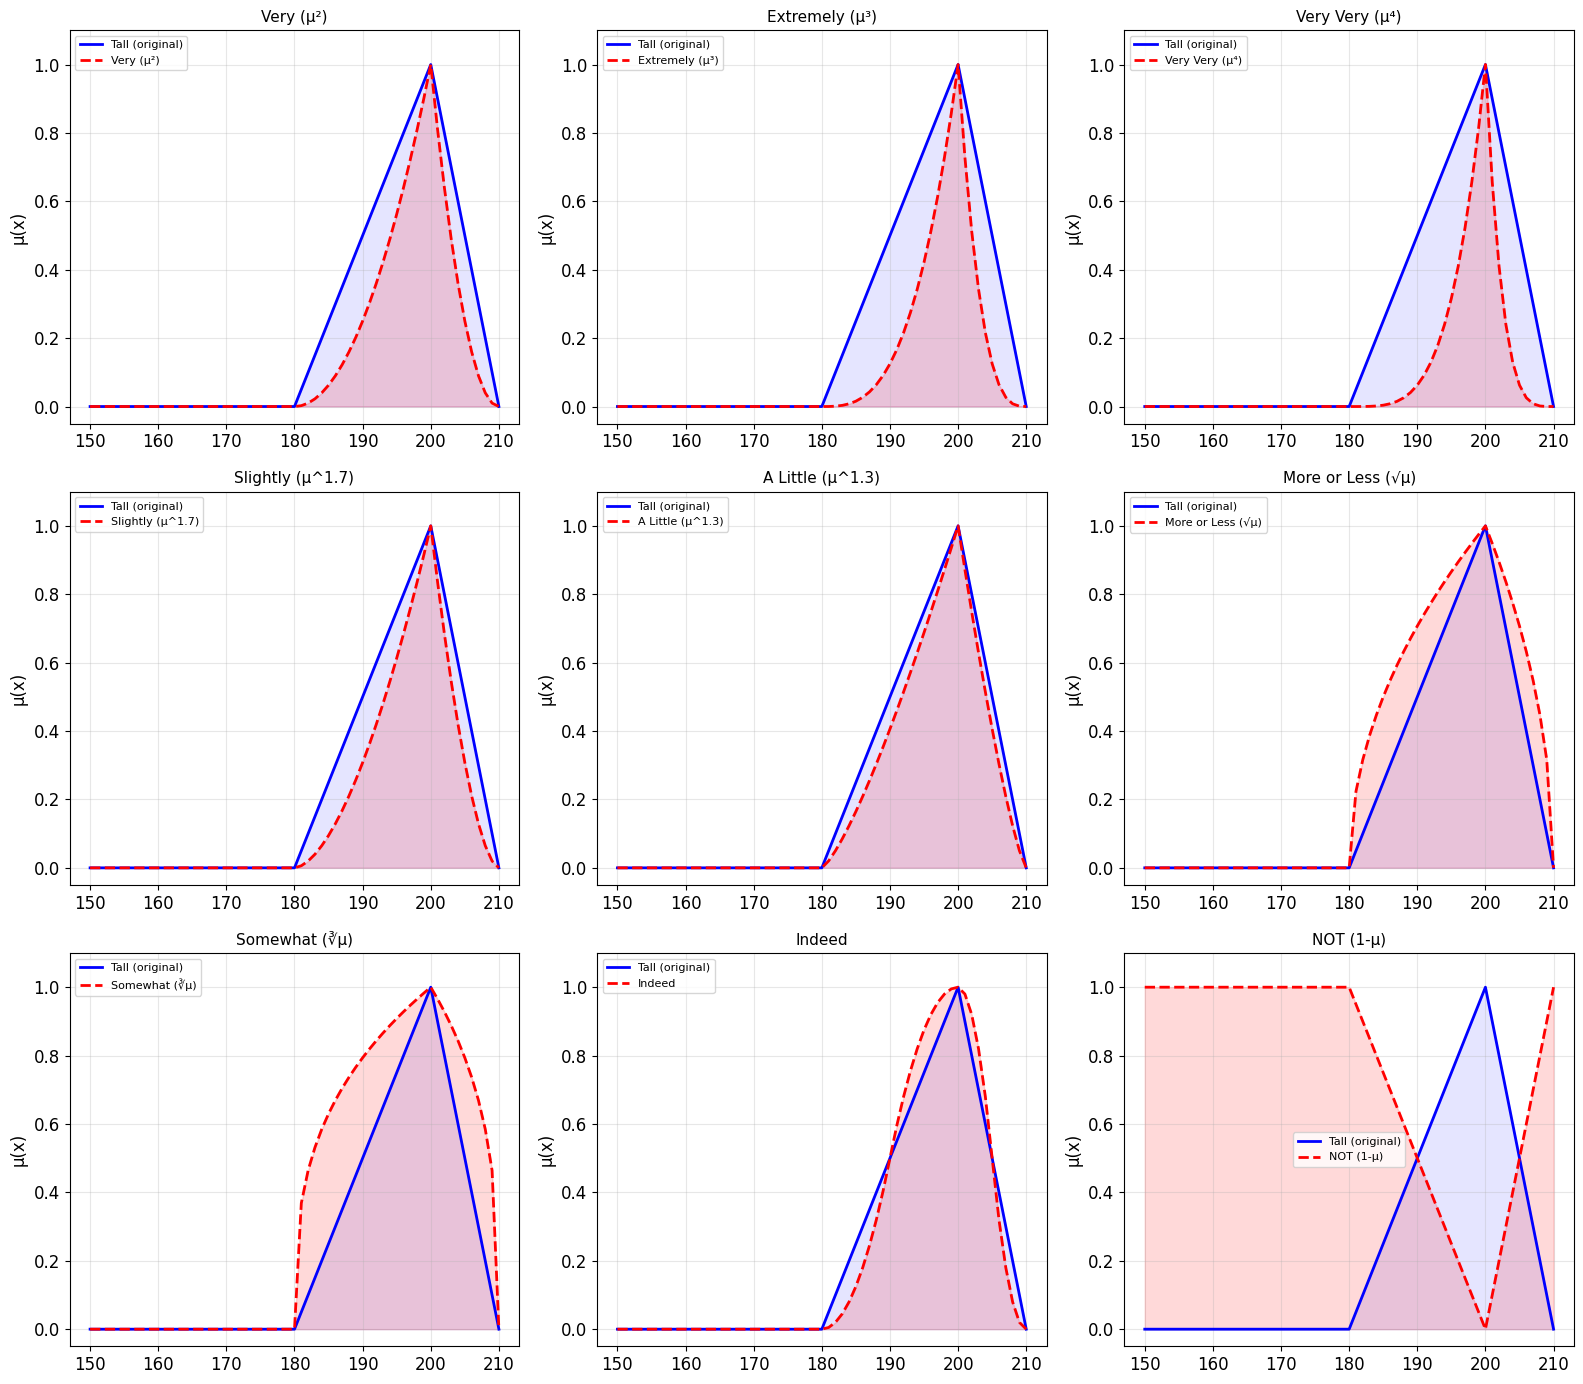

In [11]:
x_height = np.arange(150, 211, 1)
tall = fuzz.trimf(x_height, [180, 200, 210])
hedges = {
 'Very (μ²)': hedge_very,
 'Extremely (μ³)': hedge_extremely,
 'Very Very (μ⁴)': hedge_very_very,
 'Slightly (μ^1.7)': hedge_slightly,
 'A Little (μ^1.3)': hedge_a_little,
 'More or Less (√μ)': hedge_more_or_less,
 'Somewhat (∛μ)': hedge_somewhat,
 'Indeed': hedge_indeed,
 'NOT (1-μ)': hedge_not,
}
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
for ax, (name, func) in zip(axes.flat, hedges.items()):
 hedged = func(tall)
 ax.plot(x_height, tall, 'b-', linewidth=2, label='Tall (original)')
 ax.plot(x_height, hedged, 'r--', linewidth=2, label=name)
 ax.fill_between(x_height, tall, alpha=0.1, color='blue')
 ax.fill_between(x_height, hedged, alpha=0.15, color='red')
 ax.set_title(name, fontsize=11)
 ax.set_ylabel('μ(x)')
 ax.set_ylim(-0.05, 1.1)
 ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Exercise 3.3: Hedge Computations for Practice

In [15]:
mu = 0.86

print(f"Slide verification (μ = {mu}):")
print(f" Very: {hedge_very(mu):.4f} (expected: 0.7396)")
print(f" Extremely: {hedge_extremely(mu):.4f} (expected: 0.6361)")
print(f" Very Very: {hedge_very_very(mu):.4f} (expected: 0.5470)")
print(f" More or Less: {hedge_more_or_less(mu):.4f} (expected: 0.9274)")

print()

mu = 0.5
# TODO: code here to compute the hedged membership values for the
# dapping example for μ_stormy(8)

print(f"Dapping example (μ_low(10) = {mu}):")
print(f" Extremely stormy: {hedge_extremely(mu):.4f} → μ^3 = 0.125")
print(f" Slightly stormy: {hedge_slightly(mu):.4f} → μ^1.70 = 0.307")
print(f" Very stormy: {hedge_very(mu):.4f} → μ^2 = 0.25")
print()

mu = 0.3

print(f"Dapping example (μ_low(10) = {mu}):")
print(f" Very low: {hedge_very(mu):.4f} → μ^2 = 0.09")
print()

mu = 0.7

print(f"Dapping example (μ_average(10) = {mu}):")
print(f" More or less avg: {hedge_more_or_less(mu):.4f} → √0.7 ≈ 0.8367")
print()

Slide verification (μ = 0.86):
 Very: 0.7396 (expected: 0.7396)
 Extremely: 0.6361 (expected: 0.6361)
 Very Very: 0.5470 (expected: 0.5470)
 More or Less: 0.9274 (expected: 0.9274)

Dapping example (μ_low(10) = 0.5):
 Extremely stormy: 0.1250 → μ^3 = 0.125
 Slightly stormy: 0.3078 → μ^1.70 = 0.307
 Very stormy: 0.2500 → μ^2 = 0.25

Dapping example (μ_low(10) = 0.3):
 Very low: 0.0900 → μ^2 = 0.09

Dapping example (μ_average(10) = 0.7):
 More or less avg: 0.8367 → √0.7 ≈ 0.8367



## Exercise 4.1: Implement and Visualise Fuzzy Operations

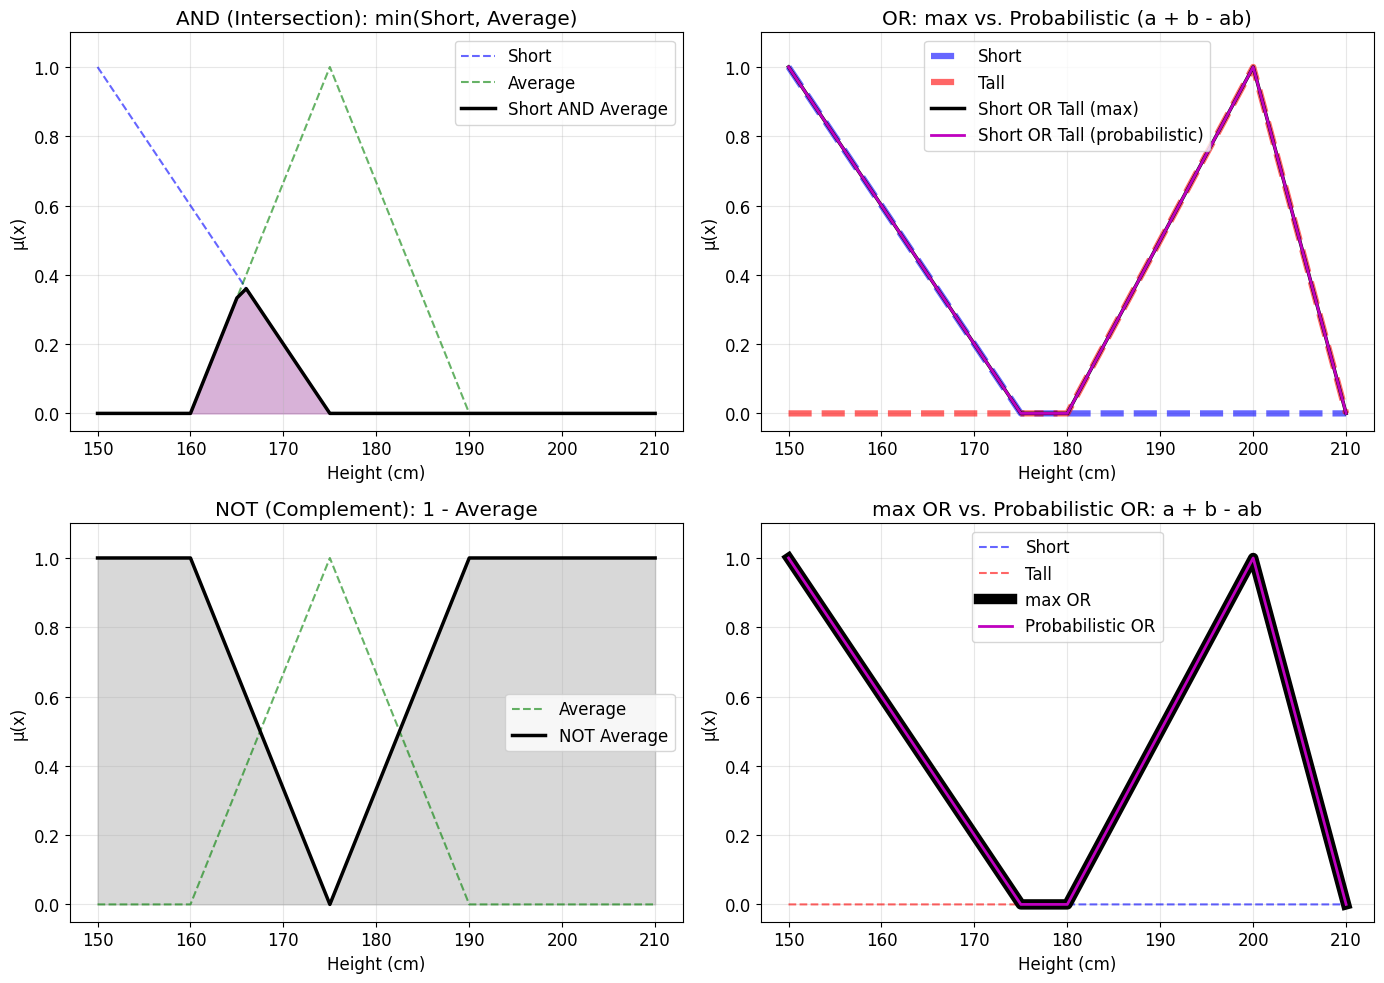

Probabilistic OR vs. max OR at height = 170 cm:
 Short(170) = 0.200, Tall(170) = 0.000
 max OR = 0.200
 prob OR = 0.200
 → When one value is 0, both methods give the same result.

 Short(182) = 0.000, Tall(182) = 0.100
 max OR = 0.100
 prob OR = 0.100


In [16]:
x_height = np.arange(150, 211, 1)
# TODO: create here the "short", "average", and "tall" sets
# as per Exercise 1.1
# Fuzzy operations
and_short_avg = np.minimum(short, average) # AND = min
or_short_tall = np.maximum(short, tall) # OR = max
not_average = 1 - average # NOT = complement
probor_short_tall = short + tall - short * tall # Probabilistic OR
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# AND
axes[0, 0].plot(x_height, short, 'b--', linewidth=1.5, alpha=0.6, label='Short')
axes[0, 0].plot(x_height, average, 'g--', linewidth=1.5, alpha=0.6, label='Average')
axes[0, 0].plot(x_height, and_short_avg, 'k-', linewidth=2.5, label='Short AND Average')
axes[0, 0].fill_between(x_height, and_short_avg, alpha=0.3, color='purple')
axes[0, 0].set_title('AND (Intersection): min(Short, Average)')
axes[0, 0].legend()
# OR
axes[0, 1].plot(x_height, short, 'b--', linewidth=4.5, alpha=0.6, label='Short')
axes[0, 1].plot(x_height, tall, 'r--', linewidth=4.5, alpha=0.6, label='Tall')
axes[0, 1].plot(x_height, or_short_tall, 'k-', linewidth=2.5, label='Short OR Tall (max)')
axes[0, 1].plot(x_height, probor_short_tall, 'm-', linewidth=2, label='Short OR Tall (probabilistic)')
axes[0, 1].set_title('OR: max vs. Probabilistic (a + b - ab)')
axes[0, 1].legend()
# TODO: plot and fill the OR (max) operation as per the AND (min) above
# NOT
axes[1, 0].plot(x_height, average, 'g--', linewidth=1.5, alpha=0.6, label='Average')
axes[1, 0].plot(x_height, not_average, 'k-', linewidth=2.5, label='NOT Average')
axes[1, 0].fill_between(x_height, not_average, alpha=0.3, color='gray')
axes[1, 0].set_title('NOT (Complement): 1 - Average')
axes[1, 0].legend()

# Probabilistic OR vs Max OR

axes[1, 1].plot(x_height, short, 'b--', linewidth=1.5, alpha=0.6, label='Short')
axes[1, 1].plot(x_height, tall, 'r--', linewidth=1.5, alpha=0.6, label='Tall')
axes[1, 1].plot(x_height, or_short_tall, 'k-', linewidth=7.5, label='max OR')
axes[1, 1].plot(x_height, probor_short_tall, 'm-', linewidth=2, label='Probabilistic OR')
axes[1, 1].set_title('max OR vs. Probabilistic OR: a + b - ab')
axes[1, 1].legend()
for ax in axes.flat:
 ax.set_xlabel('Height (cm)')
 ax.set_ylabel('μ(x)')
 ax.set_ylim(-0.05, 1.1)
plt.tight_layout()
plt.show()

# Numerical comparison
print("Probabilistic OR vs. max OR at height = 170 cm:")
h = 170
s = fuzz.interp_membership(x_height, short, h)
t = fuzz.interp_membership(x_height, tall, h)
print(f" Short({h}) = {s:.3f}, Tall({h}) = {t:.3f}")
print(f" max OR = {max(s, t):.3f}")
print(f" prob OR = {s + t - s*t:.3f}")
print(" → When one value is 0, both methods give the same result.")
print()
# TODO: code here the same comparison as above (h = 170) but now 
# for h = 182

h = 182
s = fuzz.interp_membership(x_height, short, h)
t = fuzz.interp_membership(x_height, tall, h)
print(f" Short({h}) = {s:.3f}, Tall({h}) = {t:.3f}")
print(f" max OR = {max(s, t):.3f}")
print(f" prob OR = {s + t - s*t:.3f}")